In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

zip_filename = "images.zip"  # <-- put your zip file path here

extract_folder = "dataset"
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
print(f"Extracted images to folder: {extract_folder}")

image_files = []
for root, dirs, files in os.walk(extract_folder):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            image_files.append(os.path.join(root, f))
image_files = sorted(image_files)
print(f"Found {len(image_files)} images.")
if len(image_files) == 0:
    raise ValueError("No images found in the folder. Check file types and folder structure.")



Extracted images to folder: dataset
Found 4317 images.


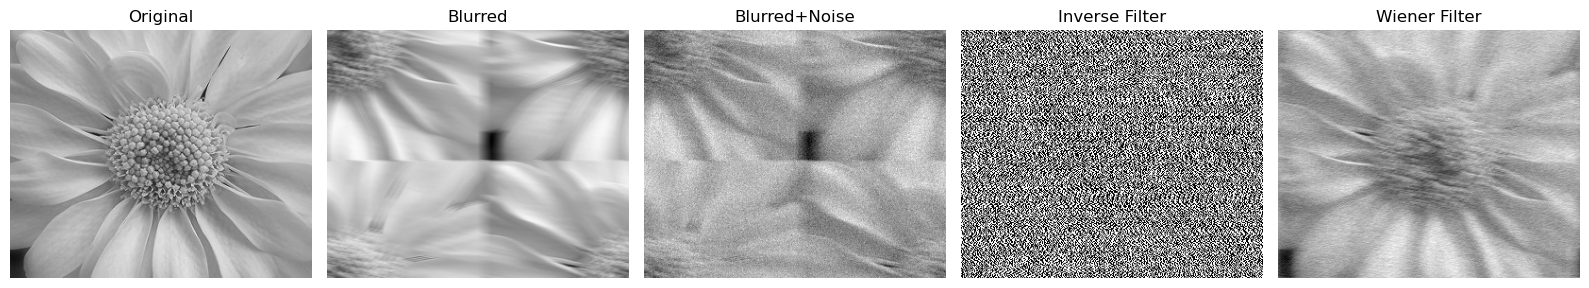

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

dataset_folder = "dataset"
image_files = [str(f) for f in Path(dataset_folder).rglob('*') if f.suffix.lower() in ('.png','.jpg','.jpeg')]
image_files = sorted(image_files)

if len(image_files) == 0:
    raise ValueError("No images found!")

img_path = image_files[0]  
orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
orig_f = orig.astype(np.float32)

psf_size = 15
psf_angle = 10
noise_sigma = 10.0

def motion_blur_psf(size=21, angle=0):
    psf = np.zeros((size, size), dtype=np.float32)
    center = size // 2
    angle_rad = np.deg2rad(angle)
    for t in range(size):
        x = center + (t - center) * np.cos(angle_rad)
        y = center + (t - center) * np.sin(angle_rad)
        xi = int(round(x))
        yi = int(round(y))
        if 0 <= xi < size and 0 <= yi < size:
            psf[yi, xi] = 1.0
    s = psf.sum()
    if s != 0:
        psf /= s
    return psf

def pad_psf_to_image(psf, img_shape):
    h, w = img_shape
    ph, pw = psf.shape
    psf_padded = np.zeros((h, w), dtype=np.float32)
    psf_padded[:ph, :pw] = psf
    psf_padded = np.fft.ifftshift(psf_padded)
    return psf_padded

def psf_filter_image(img_float, psf):
    h, w = img_float.shape
    psf_padded = pad_psf_to_image(psf, (h, w))
    H = np.fft.fft2(psf_padded)
    F = np.fft.fft2(img_float)
    G = H * F
    g = np.fft.ifft2(G).real
    return g, H

def safe_inverse_filter(degraded_float, H, eps=1e-3):
    G = np.fft.fft2(degraded_float)
    H_abs = np.abs(H)
    denom = H.copy()
    small_mask = H_abs < eps
    denom[small_mask] = eps + 0j
    F_hat = G / denom
    f_hat = np.fft.ifft2(F_hat).real
    return f_hat

def wiener_filter_freq(degraded_float, H, K):
    G = np.fft.fft2(degraded_float)
    H_conj = np.conj(H)
    H_abs2 = np.abs(H)**2
    W = H_conj / (H_abs2 + K)
    F_hat = W * G
    f_hat = np.fft.ifft2(F_hat).real
    return f_hat

def estimate_K(degraded_float, psf):
    blurred_est = cv2.filter2D(degraded_float.astype(np.float32), -1, psf, borderType=cv2.BORDER_REPLICATE)
    noise_est = degraded_float - blurred_est
    noise_var = np.var(noise_est)
    sig_var = max(np.var(degraded_float) - noise_var, 1e-8)
    K = max(noise_var / sig_var, 1e-10)
    return K

def to_uint8_clip(img_float):
    return np.clip(img_float, 0, 255).astype(np.uint8)

psf = motion_blur_psf(psf_size, psf_angle)
blurred_float, H = psf_filter_image(orig_f, psf)
blurred = to_uint8_clip(blurred_float)

noise = np.random.normal(0, noise_sigma, blurred.shape)
blurred_noise_float = blurred_float + noise
blurred_noise = to_uint8_clip(blurred_noise_float)

inv_float = safe_inverse_filter(blurred_noise_float, H, eps=1e-3)
inv_restored = to_uint8_clip(inv_float)

K = estimate_K(blurred_noise_float, psf)
wiener_float = wiener_filter_freq(blurred_noise_float, H, K)
wiener_restored = to_uint8_clip(wiener_float)


titles = ["Original", "Blurred", "Blurred+Noise", "Inverse Filter", "Wiener Filter"]
imgs = [orig, blurred, blurred_noise, inv_restored, wiener_restored]

plt.figure(figsize=(16,5))
for i, (im, t) in enumerate(zip(imgs, titles), 1):
    plt.subplot(1,5,i)
    plt.imshow(im, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()
